--- Numeric Calculation (No Gurobi) ---
Minimum point found at: (x, y) = (4.90, -10.20)
Minimum function value F(x,y) = -4.39


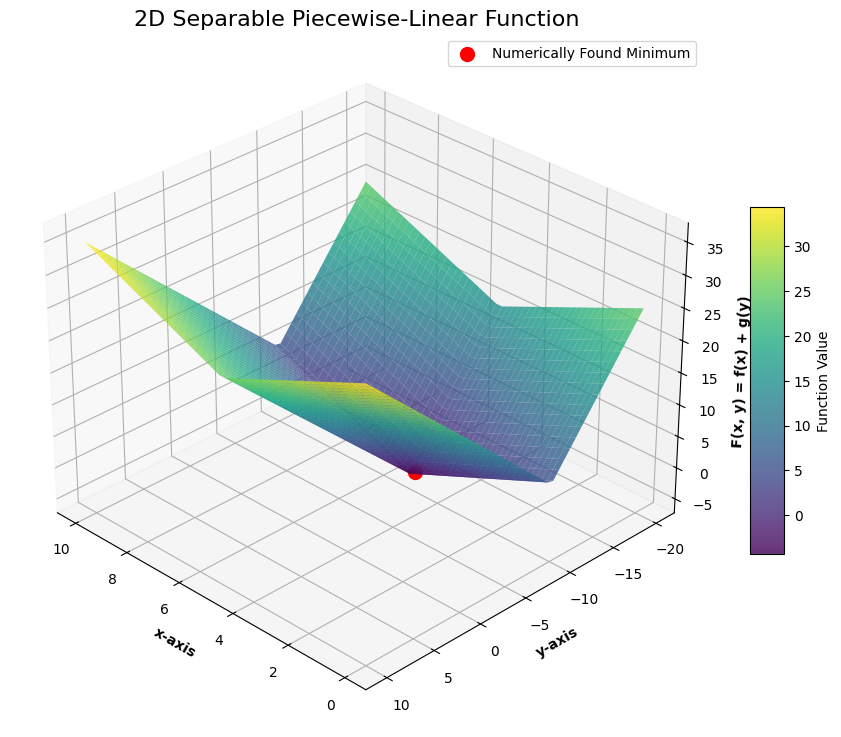

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the 1D Piecewise-Linear Functions ---

# f(x): A symmetric V-shape with its minimum at x=5
x_pts = [0.0, 5.0, 10.0]
fx_pts = [10.0, 0.0, 10.0]

# g(y): An asymmetric function with its minimum at y=-10
y_pts = [-20.0, -10.0, 10.0]
gy_pts = [15.0, -5.0, 25.0]

# Create helper functions to evaluate f(x) and g(y) for plotting
# np.interp is a NumPy function for 1D piecewise-linear interpolation.
def eval_f(x_val):
    return np.interp(x_val, x_pts, fx_pts)

def eval_g(y_val):
    return np.interp(y_val, y_pts, gy_pts)

# --- 2. Generate Data for the 2D Surface Plot ---

# Create a grid of points to plot the surface
x_grid = np.linspace(0, 10, 50)
y_grid = np.linspace(-20, 10, 50)
X, Y = np.meshgrid(x_grid, y_grid)

# Evaluate the 2D function F(x,y) = f(x) + g(y) on the grid
Z = eval_f(X) + eval_g(Y)

# --- 3. Find the Minimum Point Numerically (No Gurobi) ---

# Find the minimum value on our Z grid
min_z_val = Z.min()

# Find the index (row, col) of the minimum value in the 2D grid
min_index = np.unravel_index(np.argmin(Z), Z.shape)

# Get the x and y coordinates corresponding to that minimum point
min_x_val = X[min_index]
min_y_val = Y[min_index]

print("--- Numeric Calculation (No Gurobi) ---")
print(f"Minimum point found at: (x, y) = ({min_x_val:.2f}, {min_y_val:.2f})")
print(f"Minimum function value F(x,y) = {min_z_val:.2f}")


# --- 4. Visualize the 2D Function and the Minimum Point ---

# Create the 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection='3d')

# Plot the surface
surface = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')

# Plot the optimal point we found with NumPy
# We make it a large, red dot so it's clearly visible.
ax.scatter(min_x_val, min_y_val, min_z_val, color='red', s=100, depthshade=True, label='Numerically Found Minimum')

# Add labels and title
ax.set_xlabel('x-axis', fontweight='bold')
ax.set_ylabel('y-axis', fontweight='bold')
ax.set_zlabel('F(x, y) = f(x) + g(y)', fontweight='bold')
ax.set_title('2D Separable Piecewise-Linear Function', fontsize=16)
ax.legend()
fig.colorbar(surface, shrink=0.5, aspect=10, label='Function Value')

# Set a nice viewing angle
ax.view_init(elev=30, azim=135)

plt.show()

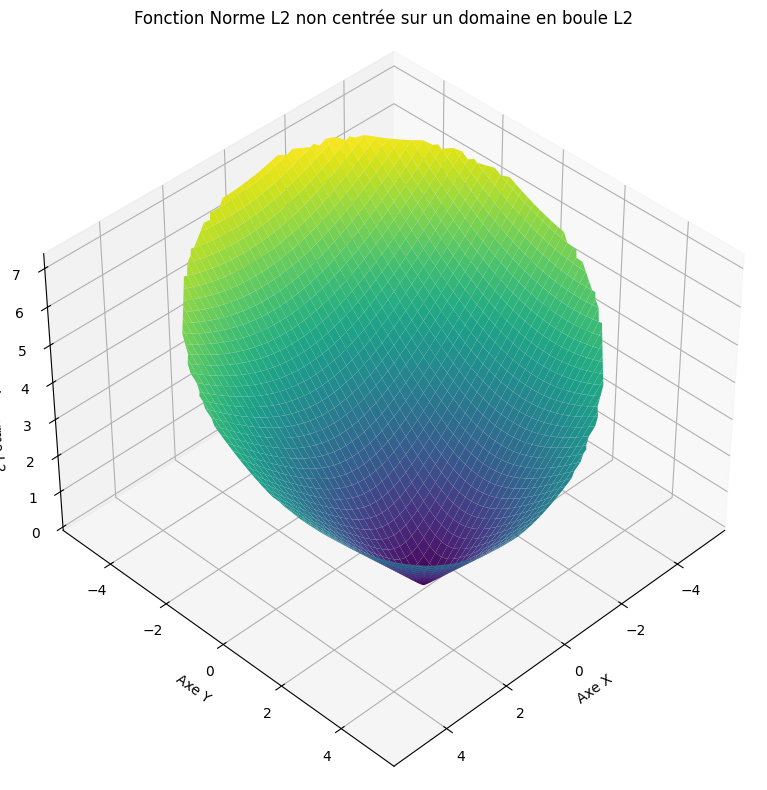

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Définir le domaine (boule L2 / disque)
radius = 5.0
# Crée des points équidistants pour les axes x et y
x = np.linspace(-radius, radius, 100)
y = np.linspace(-radius, radius, 100)
# Crée une grille de coordonnées (X, Y) à partir des axes
X, Y = np.meshgrid(x, y)

# 2. Créer un masque pour les points à l'intérieur de la boule L2
# Ce masque sera utilisé pour n'afficher que le disque
mask = X**2 + Y**2 > radius**2

# 3. Définir le centre de la fonction norme L2 (non centré à l'origine)
center_a, center_b = 1.0, 2.0

# 4. Calculer la norme L2 pour chaque point (X, Y) par rapport au centre (a, b)
# C'est la formule Z = sqrt((X-a)^2 + (Y-b)^2)
Z = np.sqrt((X - center_a)**2 + (Y - center_b)**2)

# 5. Appliquer le masque pour que le domaine soit bien la boule L2
# Les points en dehors du disque ne seront pas affichés (valeur NaN)
Z[mask] = np.nan

# 6. Créer la figure 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 7. Tracer la surface
# plot_surface dessine la surface 3D en utilisant les points X, Y, et Z
surf = ax.plot_surface(X, Y, Z, cmap='viridis', antialiased=True)

# 8. Ajouter des labels et un titre
ax.set_xlabel('Axe X')
ax.set_ylabel('Axe Y')
ax.set_zlabel('Valeur de la norme L2')
ax.set_title("Fonction Norme L2 non centrée sur un domaine en boule L2")
ax.view_init(elev=40, azim=45) # Ajuster l'angle de vue
plt.tight_layout()

# 9. Afficher ou sauvegarder le graphique
# Dans un script, vous utiliseriez plt.show() pour l'afficher
# Ici, nous sauvegardons l'image
plt.savefig("plot_norme_l2_3d.png")
# plt.show() # Décommentez pour afficher dans une fenêtre interactive

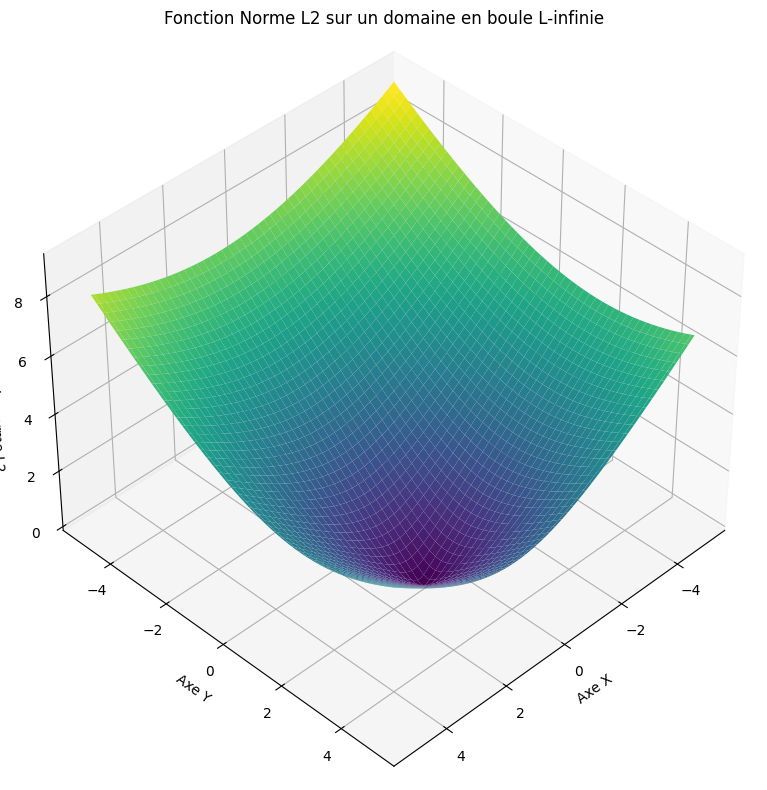

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Définir la grille de calcul
radius = 5.0
x = np.linspace(-radius, radius, 100)
y = np.linspace(-radius, radius, 100)
X, Y = np.meshgrid(x, y)

# 2. Créer un masque pour le domaine en boule L-infinie (un carré)
# La condition pour être dans le domaine est max(|X|, |Y|) <= radius.
# Le masque identifie donc les points en DEHORS du domaine.
mask = np.maximum(np.abs(X), np.abs(Y)) > radius

# 3. Définir le centre de la fonction norme L2
center_a, center_b = 1.0, 2.0

# 4. Calculer la norme L2 pour chaque point (X, Y) par rapport au centre (a, b)
Z = np.sqrt((X - center_a)**2 + (Y - center_b)**2)

# 5. Appliquer le masque pour restreindre le tracé au domaine carré
# Cette ligne est techniquement redondante car le linspace définit déjà un carré,
# mais elle est essentielle si la grille de calcul était plus grande que le domaine.
Z[mask] = np.nan

# 6. Créer la figure 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 7. Tracer la surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', antialiased=True)

# 8. Ajouter des labels et un titre
ax.set_xlabel('Axe X')
ax.set_ylabel('Axe Y')
ax.set_zlabel('Valeur de la norme L2')
ax.set_title("Fonction Norme L2 sur un domaine en boule L-infinie")
ax.view_init(elev=40, azim=45)
plt.tight_layout()

# 9. Sauvegarder la figure
plt.savefig("plot_norme_l2_linf_3d.png")
# plt.show() # À utiliser pour un affichage interactif

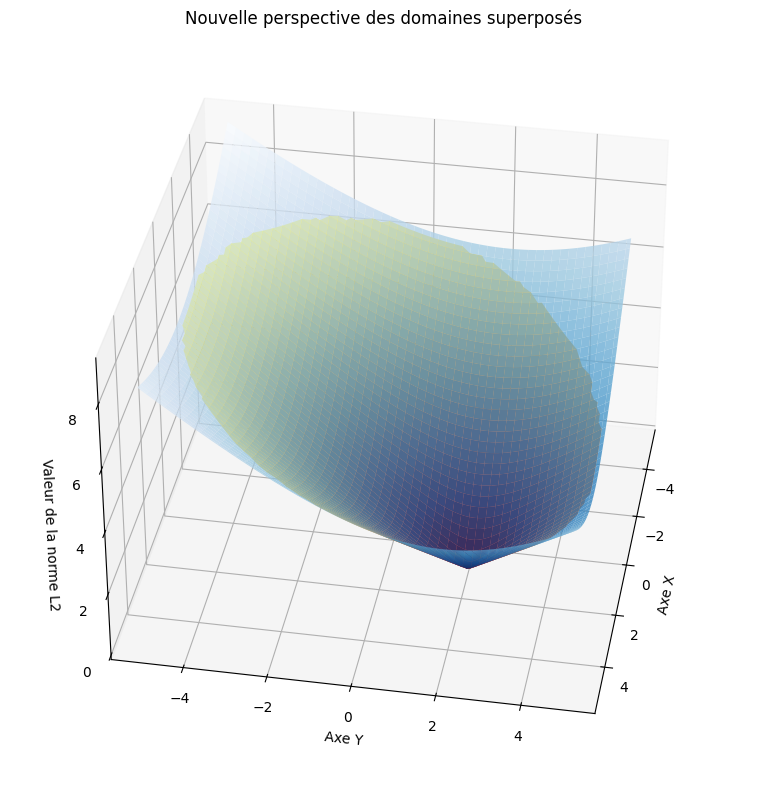

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Définir la grille de calcul commune
radius = 5.0
x = np.linspace(-radius, radius, 100)
y = np.linspace(-radius, radius, 100)
X, Y = np.meshgrid(x, y)

# 2. Définir le centre de la fonction norme L2
center_a, center_b = 1.0, 2.0

# 3. Calculer la valeur de la norme L2 sur toute la grille (domaine carré par défaut)
Z_linf = np.sqrt((X - center_a)**2 + (Y - center_b)**2)

# 4. Préparer les données pour le domaine en boule L2 (disque)
Z_l2 = Z_linf.copy()
mask_l2 = X**2 + Y**2 > radius**2
Z_l2[mask_l2] = np.nan

# 5. Créer la figure 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 6. Tracer les deux surfaces sur les mêmes axes avec de nouvelles couleurs
# Surface 1: Domaine L-infinie (carré) avec la palette 'Blues_r'
ax.plot_surface(X, Y, Z_linf, cmap='Blues_r', antialiased=True, alpha=0.8)

# Surface 2: Domaine L2 (disque) avec la palette 'autumn'
ax.plot_surface(X, Y, Z_l2, cmap='autumn', antialiased=True)

# 7. Ajouter des labels et un titre
ax.set_xlabel('Axe X')
ax.set_ylabel('Axe Y')
ax.set_zlabel('Valeur de la norme L2')
ax.set_title("Nouvelle perspective des domaines superposés")

# 8. Changer la perspective
ax.view_init(elev=35, azim=10)
plt.tight_layout()

# 9. Sauvegarder la figure
plt.savefig("plot_assemble_new_view.png")

--- Numeric Calculation on Fewer Random Samples ---
Minimum point found among samples at: (x, y) = (-1.93, -0.71)
Minimum function value Z = 2.06


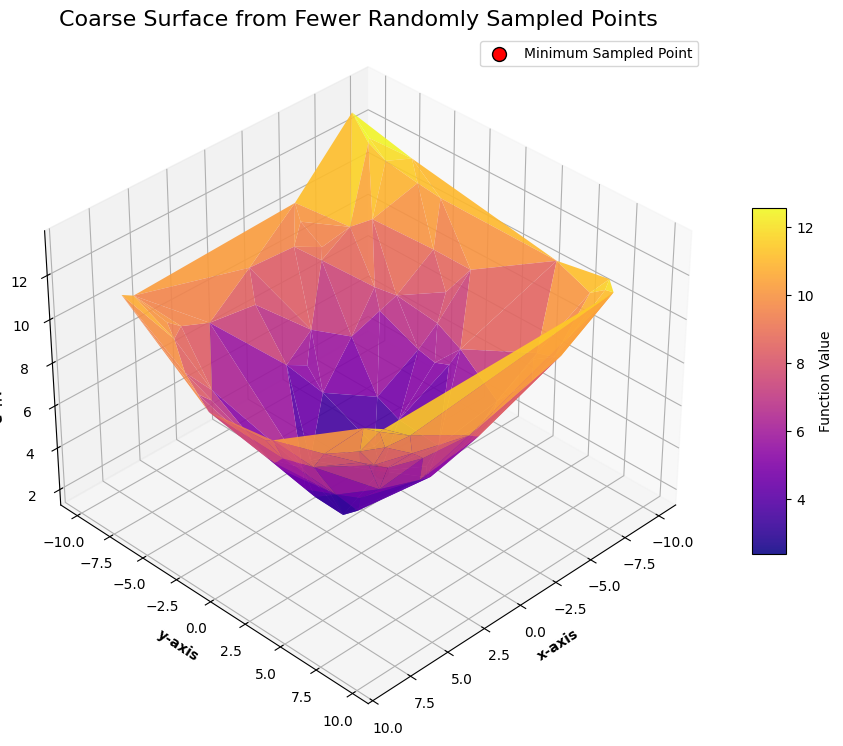

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate Fewer Randomly Sampled Points ---

# Decrease the number of points from 600 to 80
num_points = 100

# Sample x and y from a uniform distribution between -10 and 10.
x_random = np.random.uniform(-10, 10, num_points)
y_random = np.random.uniform(-10, 10, num_points)

# --- 2. Calculate Z for each random point ---
Z_random = np.sqrt(x_random**2 + y_random**2)

# --- 3. Find the minimum among the random samples ---
min_idx = np.argmin(Z_random)
min_x = x_random[min_idx]
min_y = y_random[min_idx]
min_z = Z_random[min_idx]

print("--- Numeric Calculation on Fewer Random Samples ---")
print(f"Minimum point found among samples at: (x, y) = ({min_x:.2f}, {min_y:.2f})")
print(f"Minimum function value Z = {min_z:.2f}")


# --- 4. Visualize the Function from Fewer Random Samples ---

# Create the 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection='3d')

# Use plot_trisurf which is designed to create a surface from scattered (x,y,z) points.
surface = ax.plot_trisurf(x_random, y_random, Z_random, cmap='plasma', linewidth=0.2, antialiased=True, alpha=0.9)

# Plot the minimum point found among the samples
ax.scatter(min_x, min_y, min_z, color='red', s=100, ec='black', zorder=10, depthshade=True, label='Minimum Sampled Point')

# Add labels and title
ax.set_xlabel('x-axis', fontweight='bold')
ax.set_ylabel('y-axis', fontweight='bold')
ax.set_zlabel('Z = ||(x,y)||_2', fontweight='bold')
ax.set_title('Coarse Surface from Fewer Randomly Sampled Points', fontsize=16)
ax.legend()
fig.colorbar(surface, shrink=0.5, aspect=10, label='Function Value')

# Set a viewing angle
ax.view_init(elev=35, azim=45)

plt.show()